In [12]:
# List the uploaded files.
!ls -la

total 108
drwxr-xr-x 1 root root  4096 Jul 22 16:50 .
drwxr-xr-x 1 root root  4096 Jul 22 16:41 ..
drwxr-xr-x 4 root root  4096 Jun  4 13:32 .config
-rw-r--r-- 1 root root 31181 Jul 22 16:49 dissertation_analysis.py
-rw-r--r-- 1 root root    80 Jul 22 16:50 requirements.txt
drwxr-xr-x 1 root root  4096 Jun  4 13:32 sample_data
-rw-r--r-- 1 root root 56993 Jul 22 16:49 student-mat.csv


In [13]:
# Install the required Python packages.
!pip install -q pandas numpy scikit-learn matplotlib joblib

In [14]:
# Install the exact package versions from requirements.txt.
!pip install -q -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 32.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.3.5 which is incompatible.


In [15]:
# Run the main analysis and save the results.
!python dissertation_analysis.py \
    --data student-mat.csv \
    --output-dir results

Analysis completed. Outputs written to: /content/results
Main repeated-CV summary:
configuration                    configuration_label               model  mean_accuracy  mean_balanced_accuracy  mean_f1_risk  mean_precision_risk  mean_recall_risk  standard_deviation_accuracy  standard_deviation_balanced_accuracy  standard_deviation_f1_risk  standard_deviation_precision_risk  standard_deviation_recall_risk
            A   With first- and second-period grades       Decision Tree       0.885570                0.886110      0.835602             0.793861          0.887692                     0.036629                              0.044402                    0.055524                           0.060489                        0.084499
            A   With first- and second-period grades Logistic Regression       0.913418                0.916662      0.876265             0.834309          0.926154                     0.031789                              0.032398                    0.044039    

In [16]:
# Run nested cross-validation and hyperparameter tuning.
!python dissertation_analysis.py \
    --data student-mat.csv \
    --output-dir results \
    --nested-only

Nested sensitivity analysis completed. Outputs written to: /content/results


In [17]:
# List the generated result files.
!find results -maxdepth 2 -type f | sort

results/confusion_matrices.csv
results/descriptive_statistics.csv
results/figures/balanced_accuracy.png
results/figures/class_distribution.png
results/figures/failure_recall.png
results/figures/permutation_importance_with_grades.png
results/figures/permutation_importance_without_grades.png
results/logistic_coefficients.csv
results/missing_values.csv
results/nested_cv_selected_hyperparameters.csv
results/nested_cv_summary.csv
results/original_study_comparison.csv
results/OUTPUT_MANIFEST.txt
results/permutation_importance_summary.csv
results/repeated_cv_fold_results.csv
results/repeated_cv_summary_long.csv
results/repeated_cv_summary_wide.csv
results/software_environment.json


In [18]:
# Display the main cross-validation results.
import pandas as pd

main_results = pd.read_csv("results/repeated_cv_summary_wide.csv")
main_results

,configuration,configuration_label,model,mean_accuracy,mean_balanced_accuracy,mean_f1_risk,mean_precision_risk,mean_recall_risk,standard_deviation_accuracy,standard_deviation_balanced_accuracy,standard_deviation_f1_risk,standard_deviation_precision_risk,standard_deviation_recall_risk
0,A,With first- and second-period grades,Decision Tree,0.885570,0.886110,0.835602,0.793861,0.887692,0.036629,0.044402,0.055524,0.060489,0.084499
1,A,With first- and second-period grades,Logistic Regression,0.913418,0.916662,0.876265,0.834309,0.926154,0.031789,0.032398,0.044039,0.062241,0.050783
2,A,With first- and second-period grades,Naive baseline,0.918987,0.923948,0.884058,0.835616,0.938462,0.000000,0.000000,0.000000,0.000000,0.000000
3,A,With first- and second-period grades,Random Forest,0.915443,0.918171,0.878503,0.837800,0.926154,0.029848,0.032170,0.042477,0.055823,0.051982
4,B,With first-period grade only,Decision Tree,0.782785,0.785210,0.704025,0.642545,0.792308,0.041772,0.050769,0.060916,0.064170,0.119065
5,B,With first-period grade only,Logistic Regression,0.829367,0.830508,0.762709,0.704502,0.833846,0.030380,0.034384,0.042127,0.043848,0.058456
6,B,With first-period grade only,Naive baseline,0.837975,0.828302,0.764706,0.732394,0.800000,0.000000,0.000000,0.000000,0.000000,0.000000
7,B,With first-period grade only,Random Forest,0.820759,0.813120,0.743638,0.706679,0.790769,0.037386,0.041063,0.053126,0.062656,0.076182
8,C,Without first- or second-period grades,Decision Tree,0.584810,0.568302,0.450094,0.406915,0.520000,0.062442,0.054564,0.061636,0.066461,0.111095
9,C,Without first- or second-period grades,Logistic Regression,0.651139,0.629884,0.515765,0.478038,0.567692,0.045358,0.047172,0.059164,0.055940,0.091745


In [19]:
# Display the confusion-matrix results.
confusion = pd.read_csv("results/confusion_matrices.csv")
confusion

,configuration,configuration_label,model,true_pass,false_risk_warning,missed_failure,correctly_identified_failure
0,A,With first- and second-period grades,Naive baseline,241,24,8,122
1,A,With first- and second-period grades,Logistic Regression,240,25,8,122
2,A,With first- and second-period grades,Decision Tree,232,33,10,120
3,A,With first- and second-period grades,Random Forest,241,24,9,121
4,B,With first-period grade only,Naive baseline,227,38,26,104
5,B,With first-period grade only,Logistic Regression,218,47,16,114
6,B,With first-period grade only,Decision Tree,212,53,29,101
7,B,With first-period grade only,Random Forest,223,42,27,103
8,C,Without first- or second-period grades,Naive baseline,265,0,130,0
9,C,Without first- or second-period grades,Logistic Regression,184,81,57,73


In [20]:
# Display the nested cross-validation results.
nested = pd.read_csv("results/nested_cv_summary.csv")
nested

,configuration,configuration_label,model,metric,mean,standard_deviation,outer_folds
0,A,With first- and second-period grades,Logistic Regression,accuracy,0.911392,0.023681,5
1,A,With first- and second-period grades,Logistic Regression,balanced_accuracy,0.916328,0.027421,5
2,A,With first- and second-period grades,Logistic Regression,precision_risk,0.824592,0.041750,5
3,A,With first- and second-period grades,Logistic Regression,recall_risk,0.930769,0.050148,5
4,A,With first- and second-period grades,Logistic Regression,f1_risk,0.873621,0.034530,5
5,A,With first- and second-period grades,Decision Tree,accuracy,0.888608,0.042363,5
6,A,With first- and second-period grades,Decision Tree,balanced_accuracy,0.897388,0.033723,5
7,A,With first- and second-period grades,Decision Tree,precision_risk,0.785861,0.079741,5
8,A,With first- and second-period grades,Decision Tree,recall_risk,0.923077,0.027196,5
9,A,With first- and second-period grades,Decision Tree,f1_risk,0.847103,0.049473,5


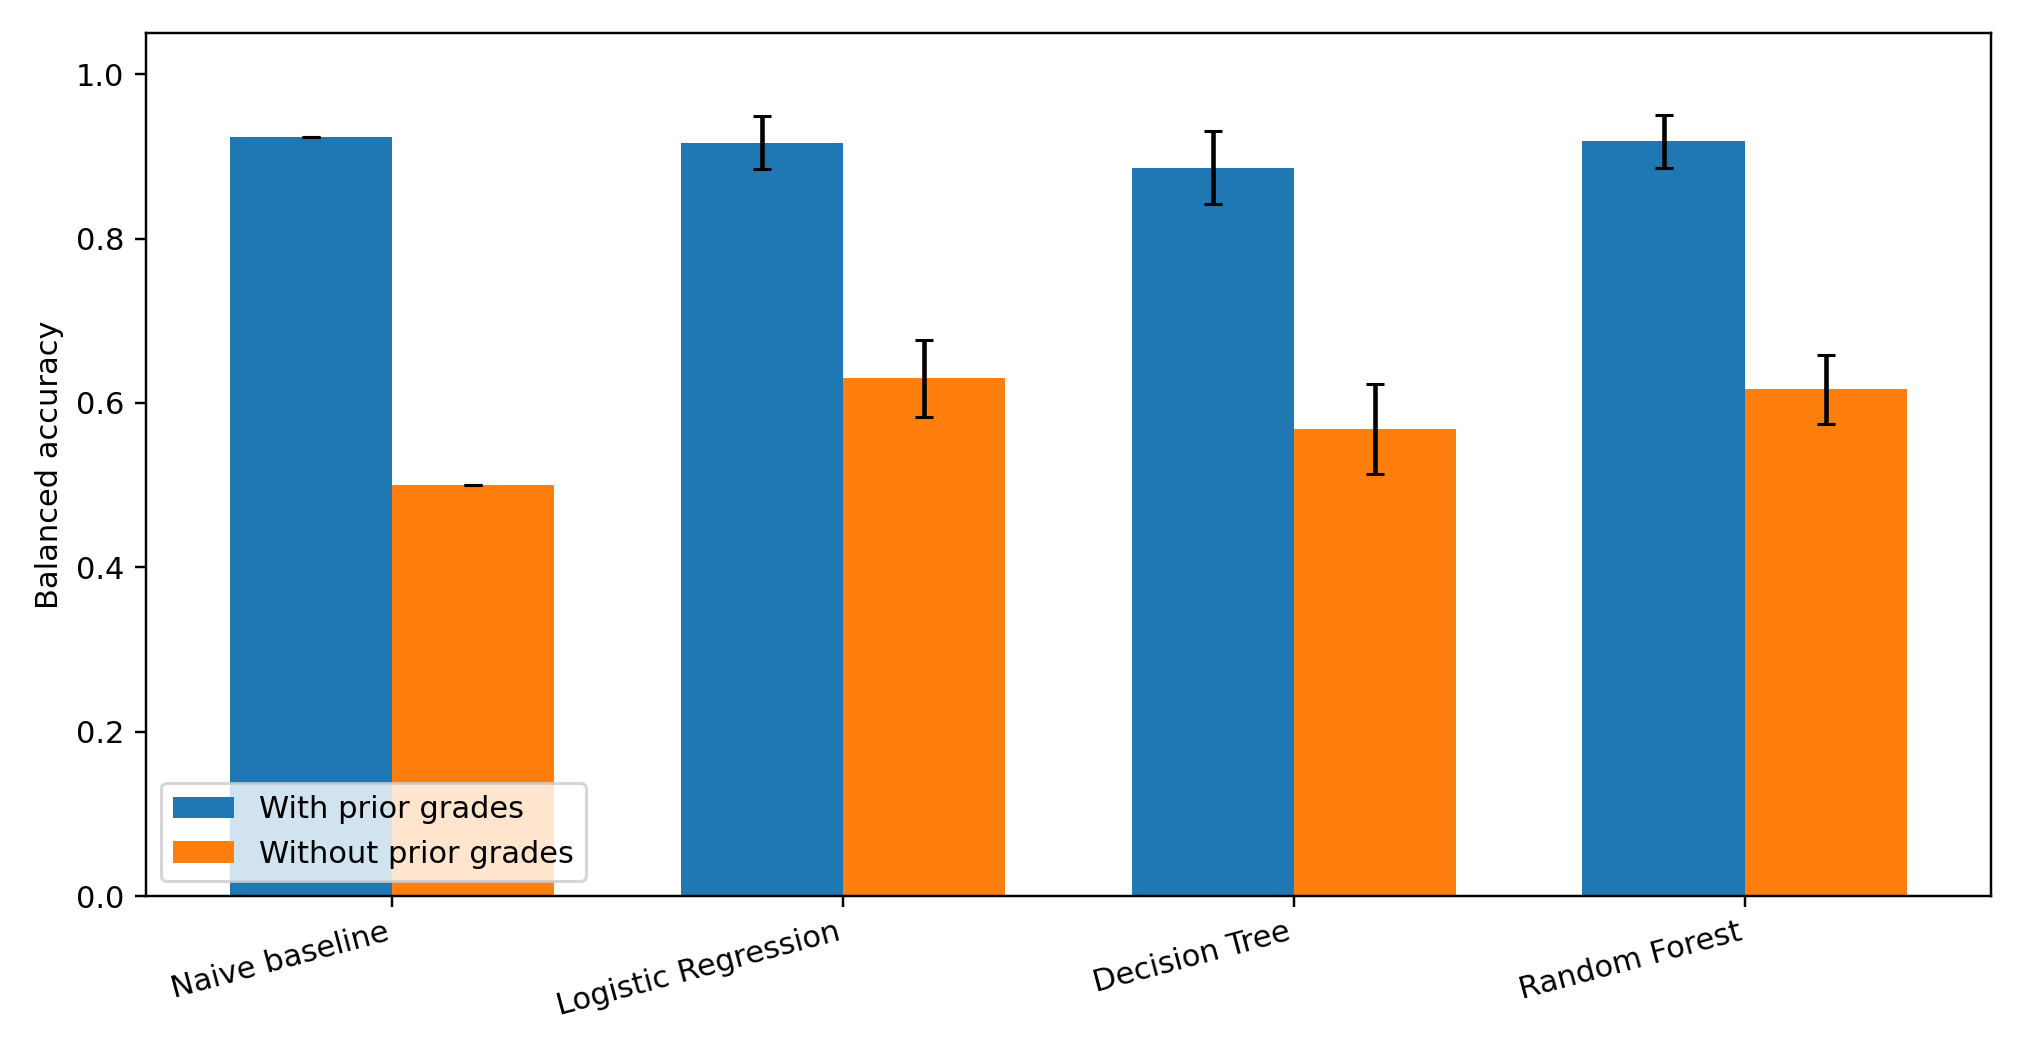

In [21]:
# Display the balanced-accuracy figure.
from IPython.display import Image, display

display(Image(filename="results/figures/balanced_accuracy.png"))

In [22]:
# Compress all results into one ZIP file.
!zip -r dissertation_results.zip results

  adding: results/ (stored 0%)
  adding: results/figures/ (stored 0%)
  adding: results/figures/class_distribution.png (deflated 28%)
  adding: results/figures/permutation_importance_without_grades.png (deflated 26%)
  adding: results/figures/permutation_importance_with_grades.png (deflated 27%)
  adding: results/figures/balanced_accuracy.png (deflated 18%)
  adding: results/figures/failure_recall.png (deflated 19%)
  adding: results/permutation_importance_summary.csv (deflated 72%)
  adding: results/repeated_cv_fold_results.csv (deflated 88%)
  adding: results/nested_cv_summary.csv (deflated 74%)
  adding: results/original_study_comparison.csv (deflated 60%)
  adding: results/confusion_matrices.csv (deflated 65%)
  adding: results/logistic_coefficients.csv (deflated 83%)
  adding: results/repeated_cv_summary_long.csv (deflated 77%)
  adding: results/missing_values.csv (deflated 40%)
  adding: results/software_environment.json (deflated 28%)
  adding: results/descriptive_statistics.csv

In [23]:
# Download the results ZIP file.
from google.colab import files

files.download("dissertation_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>